# Biological grounding: synthetic learning and logged dopamine replay

**Result: Conditional Go.** DANDI 001340 provides a scientifically defensible, action-contingent logged replay in which intact continuous dLight improves on shuffled waveforms. Coddington supplies positive causal policy-learning evidence and Jeong supplies a directionally consistent inhibition check; passive replay does not by itself identify the device kernel. Frank-style and deep-XOR learning remain separate synthetic experiments because the recording has no counterfactual dopamine for actions the animal did not choose.

The independently reconstructed preprocessing follows the published method class but is not the authors' unreleased custom implementation. The primary analysis uses all 46 substantive sessions. The pinned external rerun selected a 38-session/33,330-trial sensitivity subset at every declared detrending window; the earlier unverified 37-session/32,373-trial target did not reproduce and is not forced by a post-hoc exclusion.

In [1]:
from pathlib import Path
import csv, json, os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

RUN_PROFILE = os.getenv("MRL_RUN_PROFILE", "reduced")
DEVICE = os.getenv("MRL_DEVICE", "auto")
WORKERS = os.getenv("MRL_WORKERS", "auto")
SAVE_FIGURES = os.getenv("MRL_SAVE_FIGURES", "0") == "1"
OUTPUT_DIR = Path(os.getenv("MRL_OUTPUT_DIR", "experiments/generated_figures"))
OVERWRITE = os.getenv("MRL_OVERWRITE", "0") == "1"
RUN_EXTERNAL_DATA = os.getenv("MRL_RUN_EXTERNAL_DATA", "0") == "1"
ALLOW_DATA_DOWNLOADS = os.getenv("MRL_ALLOW_DATA_DOWNLOADS", "0") == "1"
OWNED = ("fig_probselect.png", "fig_dopamine_triage.png", "fig_dopamine_replay.png")
FIGURE_REPORT = []

def finish(fig, name):
    assert name in OWNED
    display(fig)
    if SAVE_FIGURES:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        target = OUTPUT_DIR / name
        if target.exists() and not OVERWRITE:
            raise FileExistsError(f"refusing to overwrite {target}")
        fig.savefig(target, dpi=180, bbox_inches="tight")
    FIGURE_REPORT.append(name)
    plt.close(fig)

method_provenance = {
    "synthetic_learning": "repository-specific Frank/device experiment",
    "dopamine": "DANDI:001340@0.250221.0527; independent preprocessing approximation",
    "claim_limit": "logged behavioural validation establishes an intact-waveform improvement over shuffling; kernel identity requires a separate intervention",
}


## Synthetic Frank-style learning

This remains a synthetic closed-loop experiment. No recorded dopamine or EEG value is resampled according to a simulated outcome.

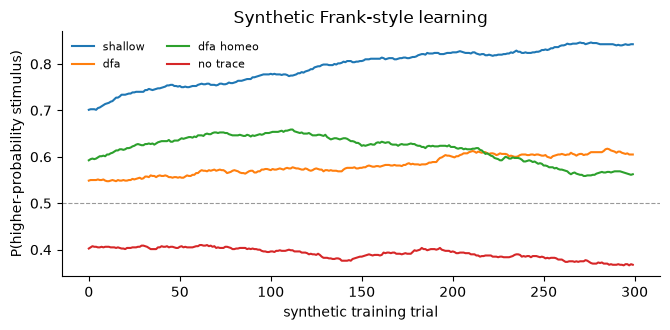

In [2]:
from mrl_trace.probselect import run_probselect
from mrl_trace.model_specs import PRIMARY_MODEL_ID, LINEAR_MODEL_ID, device_model_spec
MODEL_SPECIFICATIONS = {name: device_model_spec(name) for name in (PRIMARY_MODEL_ID, LINEAR_MODEL_ID)}

budget = {"smoke": (2, 80), "reduced": (4, 500), "publication": (20, 5000)}
seeds, trials = budget[RUN_PROFILE]
conditions = ("shallow", "dfa", "dfa_homeo", "no_trace")
frank = {name: run_probselect(name, seeds=seeds, trials=trials) for name in conditions}
fig, ax = plt.subplots(figsize=(6.8, 3.4))
for name in conditions:
    ax.plot(frank[name]["curve"], label=name.replace("_", " "))
ax.axhline(0.5, color="0.6", ls="--", lw=0.8)
ax.set(xlabel="synthetic training trial", ylabel="P(higher-probability stimulus)", title="Synthetic Frank-style learning")
ax.legend(frameon=False, ncol=2, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
finish(fig, "fig_probselect.png")


## DANDI 001340 preparation and logged replay

Downloads are doubly gated and remain opt-in. Preparation verifies the tracked 69-asset SHA-256 manifest, rejects 21 behavior-only sessions plus truncated BSD016/p118 and p119, and writes state-free non-pickle caches. Each held-out choice is predicted before its current outcome or waveform is read; the recorded choice is then teacher-forced to establish eligibility.

In [3]:
if RUN_EXTERNAL_DATA:
    from mrl_trace.dopamine import prepare_dandi001340, load_logged_session
    from mrl_trace.dopamine_replay import evaluate_logged_replay_loso, write_replay_artifacts

    raw_dir = Path(os.environ["MRL_DANDI001340_RAW_DIR"])
    cache_dir = Path(os.getenv("MRL_DANDI001340_CACHE_DIR", str(OUTPUT_DIR / "dandi001340_cache")))
    analysis_dir = Path(os.getenv("MRL_DANDI001340_OUTPUT_DIR", str(OUTPUT_DIR / "dandi001340_outputs")))
    preparation = prepare_dandi001340(
        raw_dir, cache_dir, analysis_dir,
        allow_download=ALLOW_DATA_DOWNLOADS,
    )
    sessions = [load_logged_session(path) for path in sorted((cache_dir / "window_60s").glob("*.npz"))]
    replay = evaluate_logged_replay_loso(sessions)
    replay_artifacts = write_replay_artifacts(replay, analysis_dir)

    triage = preparation["triage_trace"]
    qc_rows = list(csv.DictReader((analysis_dir / "dandi001340_qc.csv").open(encoding="utf-8")))
    status_order = ("substantive", "behavior_only", "truncated")
    status_counts = [sum(row["status"] == status for row in qc_rows) for status in status_order]
    fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.2))
    axes[0].plot(triage["time_from_outcome_s"], triage["reward_mean_dlight_z"], label="reward")
    axes[0].plot(triage["time_from_outcome_s"], triage["stochastic_omission_mean_dlight_z"], label="stochastic omission")
    axes[0].set(xlabel="time from outcome (s)", ylabel="outcome-debased dLight (z)", title="Continuous dLight triage")
    axes[0].legend(frameon=False, fontsize=8)
    axes[1].bar(range(3), status_counts, color=("#3aa07a", "#9aa6b2", "#c0392b"))
    axes[1].set_xticks(range(3), status_order, rotation=25)
    axes[1].set(ylabel="sessions", title="Explicit disposition")
    for ax in axes:
        ax.spines[["top", "right"]].set_visible(False)
    fig.suptitle("DANDI 001340 - independent preprocessing")
    fig.tight_layout()
    finish(fig, "fig_dopamine_triage.png")

    losses = replay["summary"]["pooled_log_loss"]
    order = list(losses)
    fig, ax = plt.subplots(figsize=(8.2, 3.3))
    ax.bar(range(len(order)), [losses[name] for name in order], color="#2f4b8f")
    ax.set_xticks(range(len(order)), [name.replace("_", "\n") for name in order], fontsize=7)
    ax.set(ylabel="held-out next-choice log loss", title="Logged replay - Conditional Go")
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    finish(fig, "fig_dopamine_replay.png")
else:
    print("External DANDI preparation/replay gated: set MRL_RUN_EXTERNAL_DATA=1 and provide MRL_DANDI001340_RAW_DIR.")


External DANDI preparation/replay gated: set MRL_RUN_EXTERNAL_DATA=1 and provide MRL_DANDI001340_RAW_DIR.


## Interpretation

The pinned external rerun completed for the nonlinear physical model and linear Erlang sensitivity. Pooled held-out log loss was 0.509518 for the physical device and 0.509519 for the linear sensitivity, versus 0.509559 for plain dLight, 0.509563 for the physical matched exponential, 0.509644 for shuffled physical dLight, and 0.435047 for outcome RL. The physical-minus-shuffled interval is wholly below zero, while physical-versus-plain, physical-versus-matched-exponential, and physical-versus-linear intervals include zero. This is a **Conditional Go** for action-contingent continuous-dopamine replay: Coddington supplies the positive causal learning result and Jeong/DANDI 000351 supplies a directionally consistent inhibition check; passive DANDI 001340 data reserve only discrimination among closely matched eligibility-kernel shapes.